**Context:** Cipher & Co is a brand sponsorship consultancy working with a major consumer brand preparing its next campaign. The brand wants to activate around live events — but rather than chasing a single high-profile partnership, the strategy is about presence at scale: being visible across a high volume of events in the right categories, at the right times, in the right places.
To make that case to the brand's marketing team, Cipher & Co needs a data-backed view of where the live events calendar is most active. Which event categories generate the most activity? Which UK cities and regions see the highest concentration of events? And are there time windows — particular weeks or months — where event density spikes in ways that would amplify a campaign's reach?
Your team has been brought in to map that landscape. The work is primarily descriptive, but description in service of a decision: the output should be clear enough that Cipher & Co can walk into the brand meeting and say precisely where, when, and in what categories their client should be showing up.

>**Central question to answer:** Which event categories, UK geographies, and time windows offer the highest density of live events for a brand campaign seeking maximum visibility across the events calendar?

The following questions should be considered:

* Which event segments and genres account for the greatest share of live event activity?
* Where in the UK is event density highest — and does that vary meaningfully by category?
* Are there specific time windows where event volume concentrates, and how predictable is that pattern?

In [1]:
import requests
import pandas
import os
from dotenv import load_dotenv
from pprint import pprint
from datetime import datetime as dt

In [2]:
load_dotenv()

api_key = os.getenv('API_KEY')

In [3]:

base_url = 'https://app.ticketmaster.com/discovery/v2/'
endpoint = 'events.json'
full_url = f'{base_url}{endpoint}'
params = {
  'apikey': api_key,
  'size': 1,
  'page': 2,
  'countryCode': 'GB'
}

try:
  response = requests.get(full_url, params=params)
  response.raise_for_status()
  data = response.json()
  
except requests.exceptions.HTTPError as err:
  print(f"A HTTP error occurred: {err}")  
  
except requests.exceptions.RequestException as err:
  print(f"There was an issue with the request: {err}")

In [4]:
pprint(data)

{'_embedded': {'events': [{'_embedded': {'attractions': [{'_links': {'self': {'href': '/discovery/v2/attractions/K8vZ9171Qi7?locale=en-us'}},
                                                          'classifications': [{'family': False,
                                                                               'genre': {'id': 'KnvZfZ7vAv1',
                                                                                         'name': 'Hip-Hop/Rap'},
                                                                               'primary': True,
                                                                               'segment': {'id': 'KZFzniwnSyZfZ7v7nJ',
                                                                                           'name': 'Music'},
                                                                               'subGenre': {'id': 'KZazBEonSMnZfZ7vkdA',
                                                                                            'n

In [5]:
data.keys()

dict_keys(['_embedded', '_links', 'page'])

In [6]:
event_data = data['_embedded']['events'][0]
event_data

{'name': 'JAY-Z - 30',
 'type': 'event',
 'id': '17u8v0G6CksBAD4',
 'test': False,
 'url': 'https://www.ticketmaster.co.uk/jayz-30-london-04-09-2026/event/350064E1B1E85ED5',
 'locale': 'en-us',
 'images': [{'ratio': '16_9',
   'url': 'https://s1.ticketm.net/dam/a/4ec/1e6d3beb-bfd6-4d63-a460-63cb6125f4ec_RETINA_PORTRAIT_16_9.jpg',
   'width': 640,
   'height': 360,
   'fallback': False},
  {'ratio': '4_3',
   'url': 'https://s1.ticketm.net/dam/a/4ec/1e6d3beb-bfd6-4d63-a460-63cb6125f4ec_CUSTOM.jpg',
   'width': 305,
   'height': 225,
   'fallback': False},
  {'ratio': '16_9',
   'url': 'https://s1.ticketm.net/dam/a/4ec/1e6d3beb-bfd6-4d63-a460-63cb6125f4ec_SOURCE',
   'width': 2426,
   'height': 1365,
   'fallback': False},
  {'ratio': '3_2',
   'url': 'https://s1.ticketm.net/dam/a/4ec/1e6d3beb-bfd6-4d63-a460-63cb6125f4ec_TABLET_LANDSCAPE_3_2.jpg',
   'width': 1024,
   'height': 683,
   'fallback': False},
  {'ratio': '16_9',
   'url': 'https://s1.ticketm.net/dam/a/4ec/1e6d3beb-bfd6-4d63-

In [7]:
name = event_data['name']
name

'JAY-Z - 30'

In [8]:
classification_data = event_data['classifications'][0]
classification_data

{'primary': True,
 'segment': {'id': 'KZFzniwnSyZfZ7v7nJ', 'name': 'Music'},
 'genre': {'id': 'KnvZfZ7vAv1', 'name': 'Hip-Hop/Rap'},
 'subGenre': {'id': 'KZazBEonSMnZfZ7vaEI', 'name': 'Trap'},
 'type': {'id': 'KZAyXgnZfZ7v7nI', 'name': 'Undefined'},
 'subType': {'id': 'KZFzBErXgnZfZ7v7lJ', 'name': 'Undefined'},
 'family': False}

In [9]:
segment = classification_data['segment']['name']
segment

'Music'

In [10]:
genre = classification_data['genre']['name']
genre

'Hip-Hop/Rap'

In [11]:
sub_genre = classification_data['subGenre']['name']
sub_genre

'Trap'

In [12]:
type_ = classification_data['type']['name']
type_

'Undefined'

In [13]:
sub_type = classification_data['subType']['name']
sub_type

'Undefined'

In [14]:
sales_dates = event_data['sales']
sales_dates

{'public': {'startDateTime': '2026-07-10T09:00:00Z',
  'startTBD': False,
  'startTBA': False,
  'endDateTime': '2026-09-04T22:59:00Z'},
 'presales': [{'startDateTime': '2026-07-09T09:00:00Z',
   'endDateTime': '2026-07-10T08:00:00Z',
   'name': 'Priority from O2',
   'description': 'Available to O2 Priority Customers. Eligible fans must access this sale from the link below or the O2 Priority app. No presale code is required.',
   'shortDescription': 'Exclusive Presale for O2 Priority Customers',
   'linkDescription': 'Access Priority from O2 Presale',
   'url': 'https://priority.o2.co.uk/'},
  {'startDateTime': '2026-07-09T12:00:00Z',
   'endDateTime': '2026-07-10T08:00:00Z',
   'name': 'Partner Presale'},
  {'startDateTime': '2026-07-09T12:00:00Z',
   'endDateTime': '2026-07-10T08:00:00Z',
   'name': 'Live Nation Presale',
   'description': 'Fans must be signed in to their My Live Nation account and access the presale through the Live Nation website. No code required',
   'shortDescr

In [15]:
start_sales_date = sales_dates['public']['startDateTime']
start_sales_date = dt.fromisoformat(start_sales_date.replace('Z', '+00:00'))
start_sales_date

datetime.datetime(2026, 7, 10, 9, 0, tzinfo=datetime.timezone.utc)

In [16]:
end_sales_date = sales_dates['public']['endDateTime']
end_sales_date = dt.fromisoformat(end_sales_date.replace('Z', '+00:00'))
end_sales_date

datetime.datetime(2026, 9, 4, 22, 59, tzinfo=datetime.timezone.utc)

In [17]:
sales_period = end_sales_date - start_sales_date
sales_period

datetime.timedelta(days=56, seconds=50340)

In [18]:
venue = event_data['_embedded']['venues'][0]
venue

{'name': 'Tottenham Hotspur Stadium',
 'type': 'venue',
 'id': 'KovZ9177OxV',
 'test': False,
 'url': 'https://www.ticketmaster.co.uk/tottenham-hotspur-stadium-tickets-london/venue/434396',
 'locale': 'en-us',
 'postalCode': 'N17 0BX',
 'timezone': 'Europe/London',
 'city': {'name': 'London'},
 'country': {'name': 'Great Britain', 'countryCode': 'GB'},
 'address': {'line1': '782 High Rd'},
 'location': {'longitude': '-0.06787000', 'latitude': '51.60081900'},
 'markets': [{'name': 'All of United Kingdom', 'id': '201'}],
 'dmas': [{'id': 601}],
 'upcomingEvents': {'ticketmaster': 10, '_total': 10, '_filtered': 0},
 'ada': {'adaPhones': 'https://www.tottenhamhotspurstadium.com/plan-your-visit/accessibility/ (copy to browser)',
  'adaCustomCopy': 'Accessible tickets at Tottenham Hotspur Stadium are sold by the venue, including all presale tickets. \n\nTo help plan your visit, Accessibility information can be found on the venue using the below URL:\nhttps://www.tottenhamhotspurstadium.com/p

In [19]:
city = venue['city']['name']
city

'London'

In [20]:
venue_name = venue['name']
venue_name

'Tottenham Hotspur Stadium'

In [21]:
latitude = venue['location']['latitude']
longitude = venue['location']['longitude']

longitude, latitude

('-0.06787000', '51.60081900')

In [22]:
date_data = event_data['dates']
date_data

{'start': {'localDate': '2026-09-04',
  'localTime': '17:00:00',
  'dateTime': '2026-09-04T16:00:00Z',
  'dateTBD': False,
  'dateTBA': False,
  'timeTBA': False,
  'noSpecificTime': False},
 'timezone': 'Europe/London',
 'status': {'code': 'offsale'},
 'spanMultipleDays': False}

In [23]:
date = date_data['start']['localDate']
date = dt.strptime(date, '%Y-%m-%d')
date

datetime.datetime(2026, 9, 4, 0, 0)

In [24]:
time = date_data['start']['localTime']
time = dt.strptime(time, '%H:%M:%S').time()
time

datetime.time(17, 0)

In [25]:
multi_day_event = date_data['spanMultipleDays']
multi_day_event

False

In [26]:
url = "https://www.wikidata.org/w/api.php"

params = {
    "action": "wbsearchentities",
    "search": venue_name,
    "language": "en",
    "format": "json"
}

headers = {
    "User-Agent": "VenueCapacityLookup/1.0"
}

try:
  response = requests.get(url, params=params, headers=headers, timeout=10)
  response.raise_for_status()

  data = response.json()

  for result in data["search"]:
      print(result["id"], result["label"])
      
except requests.exceptions.HTTPError as e:
  print(f'A HTTP Error occurred: {e}')

Q55074091 Tottenham Hotspur Stadium


In [27]:
venue_id = result['id']
venue_id

'Q55074091'

In [28]:
result

{'id': 'Q55074091',
 'title': 'Q55074091',
 'pageid': 55148294,
 'concepturi': 'http://www.wikidata.org/entity/Q55074091',
 'repository': 'wikidata',
 'url': '//www.wikidata.org/wiki/Q55074091',
 'display': {'label': {'value': 'Tottenham Hotspur Stadium', 'language': 'en'},
  'description': {'value': 'stadium in London, England', 'language': 'en'}},
 'label': 'Tottenham Hotspur Stadium',
 'description': 'stadium in London, England',
 'match': {'type': 'label',
  'language': 'en',
  'text': 'Tottenham Hotspur Stadium'}}

In [29]:
query = f"""
SELECT ?venue ?venueLabel ?capacity WHERE {{
  ?venue rdfs:label "{venue_name}"@en .
  OPTIONAL {{ ?venue wdt:P1083 ?capacity . }}

  SERVICE wikibase:label {{
    bd:serviceParam wikibase:language "en".
  }}
}}
"""

url = "https://query.wikidata.org/sparql"

headers = {
    "User-Agent": "VenueCapacityLookup/1.0"
}

response = requests.get(
    url,
    params={
        "query": query,
        "format": "json"
    },
    headers=headers
)

data = response.json()

for result in data["results"]["bindings"]:
    print("Venue:", result["venueLabel"]["value"])
    
    if "capacity" in result:
        print("Capacity:", result["capacity"]["value"])
    else:
        print("Capacity not found")

Venue: Tottenham Hotspur Stadium
Capacity: 62850


In [30]:
capacity = result["capacity"]["value"]
capacity

'62850'

## TO-DO

Extract 

    event_id
    name
    date
    time
    multi_day_event
    city
    longitude 
    latitude 
    venue
    capacity
    segment
    genre
    sub_genre

For each event using the Ticketmaster and Wikidata API calls. Store this as a csv file. A dataset containing 50,000 UK events in the next year should be generated.

In [31]:
import os
import time
import requests
from datetime import datetime, timedelta, timezone
from dotenv import load_dotenv

load_dotenv()

API_KEY  = os.getenv('API_KEY')
BASE_URL = 'https://app.ticketmaster.com/discovery/v2/events.json'

PAGE_SIZE     = 2   # max is 200 per page
MAX_PAGES     = 1    # per date window (PAGE_SIZE × MAX_PAGES = 1 event per window)
REQUEST_DELAY = 0.25  # seconds between pages — stays well inside rate limit

def build_date_windows(months: int=2, window_months: int=2) -> list[tuple[str, str]]:
    """
    Split the next `months` months into windows of `window_months` each.
    Returns (startDateTime, endDateTime) pairs in Ticketmaster's ISO 8601 format.

    A single countryCode=GB query is capped at 10,000 results. Splitting into
    bi-monthly windows gives up to 6 × 10,000 = 60,000 slots before deduplicating.
    """
    now     = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
    end_all = now + timedelta(days=30 * months)
    windows = []

    cursor = now
    while cursor < end_all:
        window_end = min(cursor + timedelta(days=30 * window_months), end_all)
        windows.append((
            cursor.strftime('%Y-%m-%dT%H:%M:%SZ'),
            window_end.strftime('%Y-%m-%dT%H:%M:%SZ'),
        ))
        cursor = window_end

    return windows

def fetch_events(
    start_dt: str,
    end_dt: str,
    seen_ids: set[str],
) -> list[dict]:
    """
    Fetch all available GB events within a single date window, paginating
    until the API has no more pages or MAX_PAGES is reached.

    Already-seen event IDs (from previous windows or a checkpoint) are
    filtered out before returning so the caller always receives only new events.

    Args:
        start_dt:  Window start in ISO 8601 format, e.g. "2026-07-08T00:00:00Z"
        end_dt:    Window end in ISO 8601 format
        seen_ids:  Set of event IDs already collected — mutated in place as
                   new IDs are encountered, so cross-window dedup is automatic.

    Returns:
        List of raw event dicts (each is the full Ticketmaster event object).
    """
    session    = requests.Session()
    new_events = []

    for page in range(MAX_PAGES):
        params = {
            'apikey':        API_KEY,
            'countryCode':   'GB',
            'startDateTime': start_dt,
            'endDateTime':   end_dt,
            'size':          PAGE_SIZE,
            'page':          page,
            'sort':          'date,asc',
        }

        try:
            response = session.get(BASE_URL, params=params, timeout=15)

            # Ticketmaster returns 429 when rate-limited — back off and retry once
            if response.status_code == 429:
                print(f'  Rate limited on page {page} — waiting 30s')
                time.sleep(30)
                response = session.get(BASE_URL, params=params, timeout=15)

            response.raise_for_status()
            data = response.json()

        except requests.exceptions.HTTPError as err:
            print(f'  HTTP error on page {page}: {err}')
            break
        except requests.exceptions.RequestException as err:
            print(f'  Request error on page {page}: {err}')
            break

        page_info   = data.get('page', {})
        total_pages = page_info.get('totalPages', 0)
        events      = data.get('_embedded', {}).get('events', [])

        if not events:
            break

        # Filter to events we haven't seen yet, then register them
        for event in events:
            event_id = event.get('id')
            if event_id and (event_id not in seen_ids): # check if event has ID and that ID has not already been seen
                seen_ids.add(event_id)
                new_events.append(event)

        print(
            f'  [{start_dt[:10]} to {end_dt[:10]}] '
            f'page {page + 1}/{total_pages} — '
            f'+{len(events)} fetched, {len(new_events)} new so far'
        )

        # Stop if we've exhausted all pages for this window
        if page + 1 >= total_pages:
            break

        time.sleep(REQUEST_DELAY)

    return new_events

In [32]:
build_date_windows()

[('2026-07-08T00:00:00Z', '2026-09-06T00:00:00Z')]

In [33]:
events = fetch_events(start_dt=build_date_windows()[0][0], end_dt=build_date_windows()[0][1], seen_ids=set())
events

  [2026-07-08 to 2026-09-06] page 1/5000 — +2 fetched, 2 new so far


[{'name': 'Row C Start',
  'type': 'event',
  'id': 'ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1',
  'test': False,
  'url': 'https://www.eticketing.co.uk/asmglobalmanchester',
  'locale': 'en-us',
  'images': [{'ratio': '16_9',
    'url': 'https://s1.ticketm.net/dam/c/8cf/a6653880-7899-4f67-8067-1f95f4d158cf_124761_EVENT_DETAIL_PAGE_16_9.jpg',
    'width': 205,
    'height': 115,
    'fallback': True},
   {'ratio': '3_2',
    'url': 'https://s1.ticketm.net/dam/c/8cf/a6653880-7899-4f67-8067-1f95f4d158cf_124761_TABLET_LANDSCAPE_3_2.jpg',
    'width': 1024,
    'height': 683,
    'fallback': True},
   {'ratio': '16_9',
    'url': 'https://s1.ticketm.net/dam/c/8cf/a6653880-7899-4f67-8067-1f95f4d158cf_124761_TABLET_LANDSCAPE_LARGE_16_9.jpg',
    'width': 2048,
    'height': 1152,
    'fallback': True},
   {'ratio': '4_3',
    'url': 'https://s1.ticketm.net/dam/c/8cf/a6653880-7899-4f67-8067-1f95f4d158cf_124761_CUSTOM.jpg',
    'width': 305,
    'height': 225,
    'fallback': True},
   {'ratio': '1

In [34]:
def flatten_event(raw: dict) -> dict:
    """
    Extract the fields we care about from a raw Ticketmaster event dict
    and return them as a flat dictionary ready for validation.

    All values are kept as their native types (strings, bools) — type
    coercion is handled downstream by the Pydantic model.

    Args:
        raw: A single event object from the Ticketmaster API response,
             i.e. one item from data['_embedded']['events'].

    Returns:
        Flat dict with the fields defined in the output schema.
    """
    classifications = raw.get('classifications', [{}])[0]
    venues          = raw.get('_embedded', {}).get('venues', [{}])
    venue           = venues[0] if venues else {}
    location        = venue.get('location', {})
    start           = raw.get('dates', {}).get('start', {})

    return {
        'event_id':        raw.get('id'),
        'name':            raw.get('name'),
        'date':            start.get('localDate'),
        'time':            start.get('localTime') if not start.get('timeTBA') else None,
        'multi_day_event': raw.get('dates', {}).get('spanMultipleDays'),
        'city':            venue.get('city', {}).get('name'),
        'longitude':       location.get('longitude'),
        'latitude':        location.get('latitude'),
        'venue':           venue.get('name'),
        'capacity':        None,
        'segment':         classifications.get('segment', {}).get('name'),
        'genre':           classifications.get('genre', {}).get('name'),
        'sub_genre':       classifications.get('subGenre', {}).get('name'),
    }

In [35]:
flat_events = []

for event in events:
  flat_event = flatten_event(event)
  flat_events.append(flat_event)

flat_events

[{'event_id': 'ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1',
  'name': 'Row C Start',
  'date': '2024-05-25',
  'time': '19:30:00',
  'multi_day_event': False,
  'city': 'Manchester',
  'longitude': '-2.24406600',
  'latitude': '53.48816400',
  'venue': 'AO Arena',
  'capacity': None,
  'segment': None,
  'genre': None,
  'sub_genre': None},
 {'event_id': 'LvZ18QxAj1bZeL8vGSGnc',
  'name': 'EVERYWHERE AT ONCE: Dewin',
  'date': '2026-06-28',
  'time': '19:00:00',
  'multi_day_event': False,
  'city': 'Narberth, Pembrokeshire',
  'longitude': '-4.74420400',
  'latitude': '51.79891500',
  'venue': 'Queens Hall',
  'capacity': None,
  'segment': 'Music',
  'genre': 'Alternative',
  'sub_genre': 'Adult Alternative Pop/Rock'}]

In [36]:
import time
import requests

WIKIDATA_SPARQL = 'https://query.wikidata.org/sparql'
WIKIDATA_DELAY  = 0.5  # seconds between requests — Wikidata asks for polite usage

# In-memory cache: venue name, capacity (or None if not found)
# Persists for the duration of the pipeline run so each unique venue
# is only looked up once, regardless of how many events are held there.
_capacity_cache = {}

def get_venue_capacity(session: requests.Session, venue_name: str) -> int | None:
    """
    Look up the seating capacity (Wikidata property P1083) for a venue
    by its English label using a SPARQL query.

    Results are cached in memory — repeated calls for the same venue name
    return immediately without hitting the API again.

    Args:
        session:     A shared requests.Session object.
        venue_name:  The venue name string from the Ticketmaster response,
                     e.g. "Tottenham Hotspur Stadium".

    Returns:
        Integer capacity if found, None otherwise.
    """
    # Return cached result if we've seen this venue before
    if venue_name in _capacity_cache:
        return _capacity_cache[venue_name]

    # Escape any double-quotes in the venue name to keep the SPARQL string valid
    safe_name = venue_name.replace('"', '\\"')

    query = f"""
SELECT ?capacity WHERE {{
  ?venue rdfs:label "{safe_name}"@en .
  ?venue wdt:P1083 ?capacity .
}}
LIMIT 1
"""

    headers = {'User-Agent': 'EventIntelligencePipeline/1.0'}

    try:
        time.sleep(WIKIDATA_DELAY)
        response = session.get(
            WIKIDATA_SPARQL,
            params={'query': query, 'format': 'json'},
            headers=headers,
            timeout=15,
        )
        response.raise_for_status()

        bindings = response.json().get('results', {}).get('bindings', [])

        if bindings and 'capacity' in bindings[0]:
            capacity = int(bindings[0]['capacity']['value'])
            _capacity_cache[venue_name] = capacity
            return capacity

    except (requests.exceptions.RequestException, ValueError, KeyError) as e:
        print(f'  Wikidata lookup failed for "{venue_name}": {e}')

    # Cache the miss too — avoids retrying venues that aren't on Wikidata
    _capacity_cache[venue_name] = None
    return None

In [37]:
for flat_event in flat_events:
  get_venue_capacity(session=requests.session(), venue_name=flat_event['name'])

In [38]:
flat_events

[{'event_id': 'ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1',
  'name': 'Row C Start',
  'date': '2024-05-25',
  'time': '19:30:00',
  'multi_day_event': False,
  'city': 'Manchester',
  'longitude': '-2.24406600',
  'latitude': '53.48816400',
  'venue': 'AO Arena',
  'capacity': None,
  'segment': None,
  'genre': None,
  'sub_genre': None},
 {'event_id': 'LvZ18QxAj1bZeL8vGSGnc',
  'name': 'EVERYWHERE AT ONCE: Dewin',
  'date': '2026-06-28',
  'time': '19:00:00',
  'multi_day_event': False,
  'city': 'Narberth, Pembrokeshire',
  'longitude': '-4.74420400',
  'latitude': '51.79891500',
  'venue': 'Queens Hall',
  'capacity': None,
  'segment': 'Music',
  'genre': 'Alternative',
  'sub_genre': 'Adult Alternative Pop/Rock'}]

In [39]:
from pydantic import ValidationError
from models import EventRecord

def validate_event(flat: dict) -> EventRecord | None:
    """
    Validate a flattened event dict against the EventRecord Pydantic model.

    Type coercion (string → date, string → float, etc.) is handled by the
    model itself. This function just attempts construction and returns None
    if validation fails, so the caller can skip bad records without crashing.

    Args:
        flat: A flat event dict as returned by flatten_event().

    Returns:
        A validated EventRecord instance, or None if validation fails.
    """
    try:
        return EventRecord(**flat)
    except ValidationError as e:
        print(f'Validation failed for event "{flat.get("event_id")}": {e.error_count()} error(s)')
        print(e)
        return None

In [40]:
for flat_event in flat_events:
  print(validate_event(flat_event))

event_id='ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1' name='Row C Start' date=datetime.date(2024, 5, 25) time=datetime.time(19, 30) multi_day_event=False city='Manchester' longitude=-2.244066 latitude=53.488164 venue='AO Arena' capacity=None segment=None genre=None sub_genre=None
event_id='LvZ18QxAj1bZeL8vGSGnc' name='EVERYWHERE AT ONCE: Dewin' date=datetime.date(2026, 6, 28) time=datetime.time(19, 0) multi_day_event=False city='Narberth, Pembrokeshire' longitude=-4.744204 latitude=51.798915 venue='Queens Hall' capacity=None segment='Music' genre='Alternative' sub_genre='Adult Alternative Pop/Rock'


In [41]:
import csv
from pathlib import Path

DATA_DIR    = Path('data')
OUTPUT_FILE = DATA_DIR / 'events.csv'

CSV_COLUMNS = [
    'event_id', 'name', 'date', 'time', 'multi_day_event',
    'city', 'longitude', 'latitude',
    'venue', 'capacity',
    'segment', 'genre', 'sub_genre',
]

def write_csv(records: list[dict]) -> None:
    """Write all collected records to the output CSV."""
    DATA_DIR.mkdir(exist_ok=True)
    with OUTPUT_FILE.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(records)
    print(f'Wrote {len(records)} records to {OUTPUT_FILE}')

def run_pipeline(fetch_capacity: bool = True) -> None: # fetch_capacity flag will skip fetching venue capacity if set to true.
    """
    Orchestrate the full ingestion pipeline:
      1. Build date windows across the next 12 months
      2. For each window, fetch events and filter out already-seen IDs
      3. Flatten, enrich with venue capacity, and validate each event
      4. Write the final CSV once all windows are processed

    Args:
        fetch_capacity: Set to False to skip Wikidata lookups. Useful for
                        a quick test run where capacity data isn't needed yet.
    """
    DATA_DIR.mkdir(exist_ok=True)

    session           = requests.Session()
    seen_ids:  set[str]  = set()
    collected: list[dict] = []
    validation_errors = 0

    windows = build_date_windows(months=2, window_months=2)

    for idx, (start_dt, end_dt) in enumerate(windows, 1):
        print(f'\nWindow {idx}/{len(windows)}: {start_dt[:10]} to {end_dt[:10]} '
              f'(collected so far: {len(collected)})')

        raw_events = fetch_events(start_dt, end_dt, seen_ids)

        for raw in raw_events:
            flat = flatten_event(raw)

            if fetch_capacity and flat.get('venue'):
                flat['capacity'] = get_venue_capacity(session, flat['venue'])

            record = validate_event(flat)

            if record is None:
                validation_errors += 1
                continue

            collected.append(record.model_dump())

        print(f'Window {idx} done | total collected: {len(collected)}')

    print(f'\nPipeline complete | valid: {len(collected)} | '
          f'validation errors: {validation_errors}')

    write_csv(collected)

In [42]:
# run_pipeline(fetch_capacity=True)

## Cleaning Event Data

In [43]:
import pandas as pd
events = pd.read_csv('data/events.csv')
events.head()

,event_id,name,date,time,multi_day_event,city,longitude,latitude,venue,capacity,segment,genre,sub_genre
0,ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1,Row C Start,2024-05-25,19:30:00,False,Manchester,-2.244066,53.488164,AO Arena,23000.0,NaN,NaN,NaN
1,LvZ18QxAj1bZeL8vGSGnc,EVERYWHERE AT ONCE: Dewin,2026-06-28,19:00:00,False,"Narberth, Pembrokeshire",-4.744204,51.798915,Queens Hall,NaN,Music,Alternative,Adult Alternative Pop/Rock
2,LvZ18Q9qwdeVCFZZlzZeZ,Lympstone Manor Presents The Celebration of Speed,2026-07-08,12:00:00,False,Exmouth,-3.418008,50.640423,Lympstone Manor,NaN,Undefined,NaN,NaN
3,LvZ18Q-Ow9IjBuOZJDXeZ,This Machine Kills Archons,2026-07-08,17:00:00,False,London,-0.038380,51.475524,New Cross Inn,NaN,Undefined,NaN,NaN
4,LvZ18QrcLq0eI9YZMX-K9,Strassenkultur - The Hill,2026-07-08,17:00:00,False,Stratford-upon-Avon,-1.629970,52.149880,Caffeine & Machine: The Hill,NaN,Undefined,NaN,NaN


In [44]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 7106 entries, 0 to 7105
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         7106 non-null   str    
 1   name             7106 non-null   str    
 2   date             7106 non-null   str    
 3   time             7015 non-null   str    
 4   multi_day_event  7106 non-null   bool   
 5   city             7106 non-null   str    
 6   longitude        7051 non-null   float64
 7   latitude         7051 non-null   float64
 8   venue            7106 non-null   str    
 9   capacity         1006 non-null   float64
 10  segment          7102 non-null   str    
 11  genre            6849 non-null   str    
 12  sub_genre        6849 non-null   str    
dtypes: bool(1), float64(3), str(9)
memory usage: 1.4 MB


### Nulls

In [53]:
def null_vals(dataframe):
    """
    Show both number of nulls and the percentage of nulls in the whole column across a Pandas dataframe.
    """
    null_vals = dataframe.isnull().sum() # How many nulls in each column
    total_cnt = len(dataframe) # Total entries in the dataframe
    null_vals = pd.DataFrame(null_vals,columns=['null']) # Put the number of nulls in a single dataframe
    null_vals['percent'] = round((null_vals['null']/total_cnt)*100,2) # Round how many nulls are there, as %, of the df
    
    return null_vals.sort_values('percent', ascending=False) # Ordered from MOST to LEAST nulls

In [54]:
null_vals(events)

,null,percent
capacity,6100,85.84
genre,257,3.62
sub_genre,257,3.62
time,91,1.28
longitude,55,0.77
latitude,55,0.77
segment,4,0.06
name,0,0.00
event_id,0,0.00
multi_day_event,0,0.00


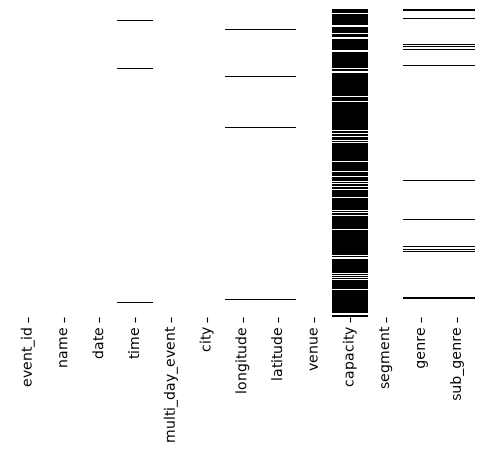

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(events.isnull(), yticklabels=False, cmap='gray_r', cbar=False);

### Check for Duplicates

In [47]:
events.duplicated().sum()

np.int64(0)

### Dropping Redundant Columns and Null Handling

In [ ]:
events.head() # first row identified as a dummy event 'Row C Start'

,event_id,name,date,time,multi_day_event,city,longitude,latitude,venue,capacity,segment,genre,sub_genre
0,ZxqgVMyxjZBYPJzwisVEJswJSIcnzynMZ6k1,Row C Start,2024-05-25,19:30:00,False,Manchester,-2.244066,53.488164,AO Arena,23000.0,NaN,NaN,NaN
1,LvZ18QxAj1bZeL8vGSGnc,EVERYWHERE AT ONCE: Dewin,2026-06-28,19:00:00,False,"Narberth, Pembrokeshire",-4.744204,51.798915,Queens Hall,NaN,Music,Alternative,Adult Alternative Pop/Rock
2,LvZ18Q9qwdeVCFZZlzZeZ,Lympstone Manor Presents The Celebration of Speed,2026-07-08,12:00:00,False,Exmouth,-3.418008,50.640423,Lympstone Manor,NaN,Undefined,NaN,NaN
3,LvZ18Q-Ow9IjBuOZJDXeZ,This Machine Kills Archons,2026-07-08,17:00:00,False,London,-0.038380,51.475524,New Cross Inn,NaN,Undefined,NaN,NaN
4,LvZ18QrcLq0eI9YZMX-K9,Strassenkultur - The Hill,2026-07-08,17:00:00,False,Stratford-upon-Avon,-1.629970,52.149880,Caffeine & Machine: The Hill,NaN,Undefined,NaN,NaN


In [50]:
events_clean = events.copy()
events_clean = events_clean.drop(index=0)
events_clean.head()

,event_id,name,date,time,multi_day_event,city,longitude,latitude,venue,capacity,segment,genre,sub_genre
1,LvZ18QxAj1bZeL8vGSGnc,EVERYWHERE AT ONCE: Dewin,2026-06-28,19:00:00,False,"Narberth, Pembrokeshire",-4.744204,51.798915,Queens Hall,NaN,Music,Alternative,Adult Alternative Pop/Rock
2,LvZ18Q9qwdeVCFZZlzZeZ,Lympstone Manor Presents The Celebration of Speed,2026-07-08,12:00:00,False,Exmouth,-3.418008,50.640423,Lympstone Manor,NaN,Undefined,NaN,NaN
3,LvZ18Q-Ow9IjBuOZJDXeZ,This Machine Kills Archons,2026-07-08,17:00:00,False,London,-0.038380,51.475524,New Cross Inn,NaN,Undefined,NaN,NaN
4,LvZ18QrcLq0eI9YZMX-K9,Strassenkultur - The Hill,2026-07-08,17:00:00,False,Stratford-upon-Avon,-1.629970,52.149880,Caffeine & Machine: The Hill,NaN,Undefined,NaN,NaN
5,LvZ18QrcYIDGeQYv1nmCq,Strassenkultur - The Bowl,2026-07-08,17:00:00,False,Bedford,-0.498880,52.051100,Caffeine & Machine: The Bowl,NaN,Undefined,NaN,NaN


The `multi_day_event` column is all False - redundant. Can be dropped.